<a href="https://colab.research.google.com/github/al07123700/Actividad-6---Prediccion-de-riesgo-de-fraude/blob/main/Actividad_6_Yasmin_Mtz_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

file_path = '/content/credit_card_fraud_10k.csv'
df_10k = pd.read_csv(file_path)
display(df_10k.head())

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [2]:
df_10k.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

## Preparación de Datos

Primero, necesitamos preparar el conjunto de datos `df_10k` para el entrenamiento del modelo. Esto incluye identificar las características (X) y la variable objetivo (y), manejar las variables categóricas y dividir los datos en conjuntos de entrenamiento y prueba.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify features (X) and target (y)
X = df_10k.drop('is_fraud', axis=1)
y = df_10k['is_fraud']

# Identify categorical and numerical columns
categorical_features = ['merchant_category'] # Based on df_10k.head() output
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove 'transaction_id' from numerical features if present, as it's an identifier, not a feature
if 'transaction_id' in numerical_features:
    numerical_features.remove('transaction_id')

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (8000, 9)
Dimensiones de X_test: (2000, 9)
Dimensiones de y_train: (8000,)
Dimensiones de y_test: (2000,)


## Modelo de Regresión Logística

Ahora, entrenaremos un modelo de Regresión Logística y evaluaremos su rendimiento utilizando el conjunto de prueba.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Create a pipeline for Logistic Regression
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42)) # 'liblinear' works well for small datasets
])

# Train the Logistic Regression model
log_reg_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_pipeline.predict(X_test)

# Evaluate the model
print("\n--- Regresión Logística ---")
print("Exactitud:", accuracy_score(y_test, y_pred_log_reg))
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_log_reg))


--- Regresión Logística ---
Exactitud: 0.9925

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.89      0.57      0.69        30

    accuracy                           0.99      2000
   macro avg       0.94      0.78      0.85      2000
weighted avg       0.99      0.99      0.99      2000



## Modelo Random Forest

Finalmente, entrenaremos un modelo Random Forest, que a menudo proporciona un mejor rendimiento para tareas de clasificación, y evaluaremos su rendimiento.

In [5]:
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline for Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the Random Forest model
rf_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate the model
print("\n--- Random Forest ---")
print("Exactitud:", accuracy_score(y_test, y_pred_rf))
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_rf))


--- Random Forest ---
Exactitud: 0.996

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.73      0.85        30

    accuracy                           1.00      2000
   macro avg       1.00      0.87      0.92      2000
weighted avg       1.00      1.00      1.00      2000



## Matriz de Confusión para Regresión Logística

Vamos a visualizar la matriz de confusión para el modelo de Regresión Logística para entender mejor los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

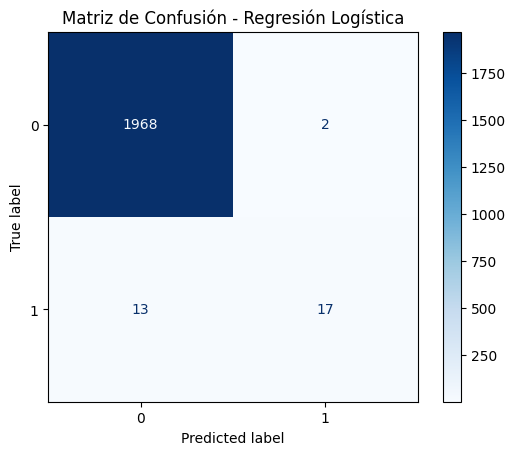

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Display confusion matrix
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg,
                                   display_labels=log_reg_pipeline.classes_)
disp_log_reg.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

## Matriz de Confusión para Random Forest

Ahora, visualicemos la matriz de confusión para el modelo Random Forest.

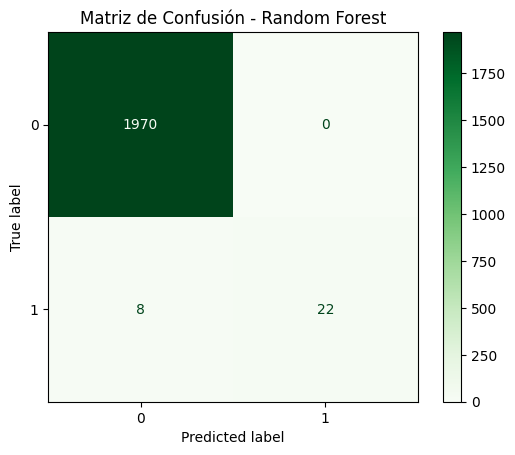

In [7]:
# Calculate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=rf_pipeline.classes_)
disp_rf.plot(cmap=plt.cm.Greens)
plt.title('Matriz de Confusión - Random Forest')
plt.show()

## Curva ROC para Regresión Logística

La curva ROC y el área bajo la curva (AUC-ROC) son métricas importantes para evaluar el rendimiento de los clasificadores binarios. Vamos a generarlas para nuestro modelo de Regresión Logística.

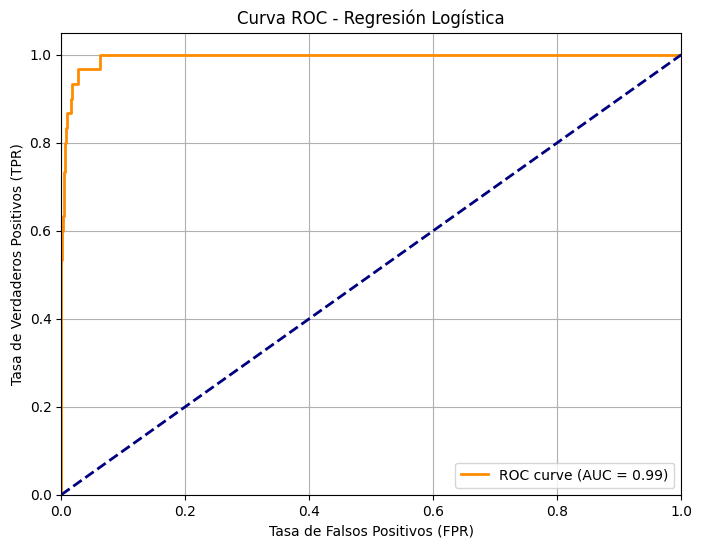

In [8]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(y_test, y_pred_proba_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Curva ROC para Random Forest

Ahora, generemos la curva ROC y el AUC-ROC para el modelo Random Forest.

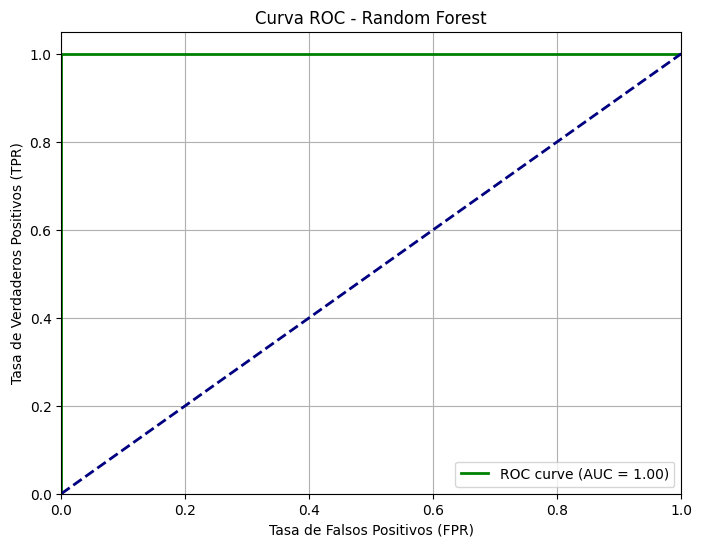

In [9]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Comparación de Curvas ROC de Modelos

Vamos a superponer las curvas ROC de ambos modelos (Regresión Logística y Random Forest) en una sola gráfica para una comparación visual más clara de su rendimiento.

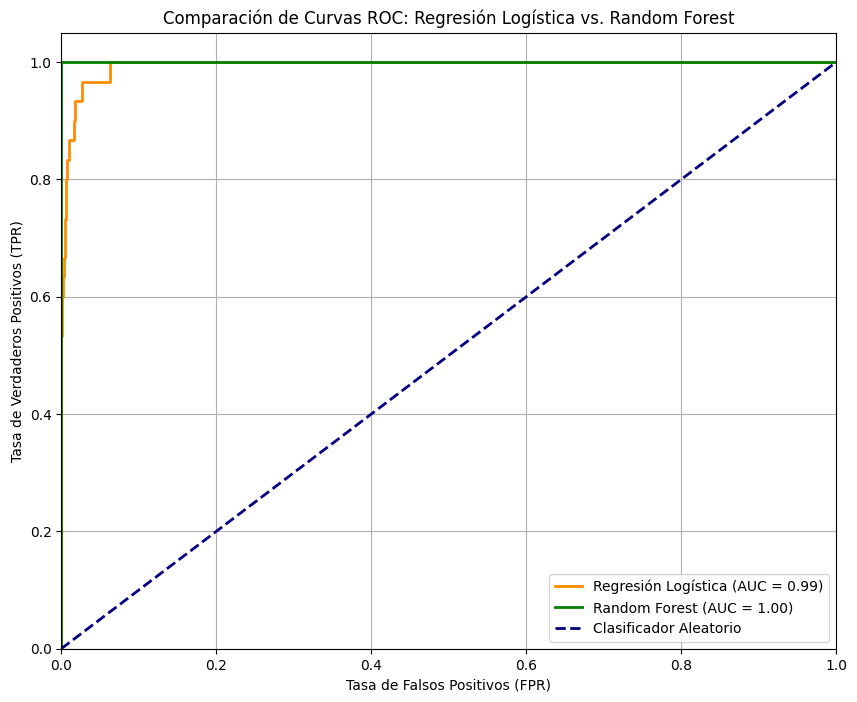

In [10]:
plt.figure(figsize=(10, 8))

# Plot ROC curve for Logistic Regression
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'Regresión Logística (AUC = {roc_auc_log_reg:.2f})')

# Plot ROC curve for Random Forest
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Plot the random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de Curvas ROC: Regresión Logística vs. Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Ajuste del Umbral de Clasificación y Curva Precision-Recall

Dado que el modelo Random Forest mostró un AUC de 1.00, lo cual es excelente pero a veces puede indicar un sobreajuste o un dataset muy separable, es útil examinar la curva Precision-Recall. Esta curva nos ayuda a elegir un umbral de clasificación que equilibre la precisión (proporción de predicciones positivas correctas) y el recall (proporción de casos positivos detectados), especialmente importante en datasets desbalanceados como la detección de fraude.

Podemos ajustar el umbral por defecto (0.5) para las predicciones del modelo para optimizar el rendimiento según nuestras necesidades específicas (por ejemplo, reducir falsos positivos o falsos negativos).

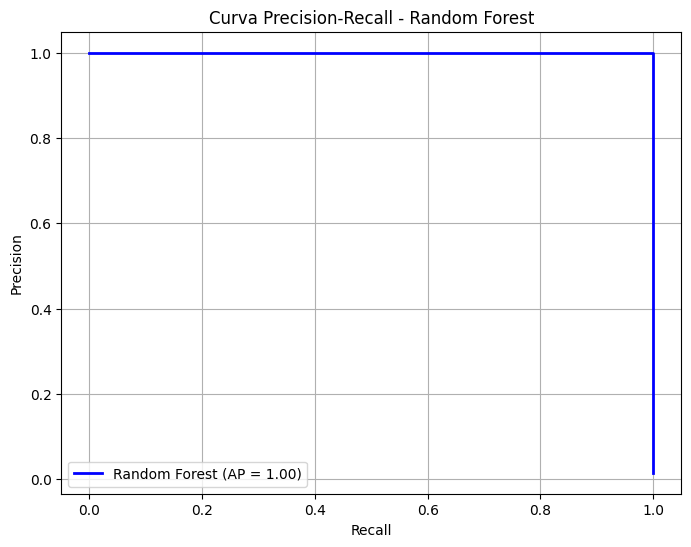

Precision, Recall, and Thresholds for Random Forest (first 10 values):
Threshold: 0.0000, Precision: 0.0150, Recall: 1.0000
Threshold: 0.0100, Precision: 0.0965, Recall: 1.0000
Threshold: 0.0200, Precision: 0.1351, Recall: 1.0000
Threshold: 0.0300, Precision: 0.1695, Recall: 1.0000
Threshold: 0.0400, Precision: 0.2098, Recall: 1.0000
Threshold: 0.0500, Precision: 0.2586, Recall: 1.0000
Threshold: 0.0600, Precision: 0.3125, Recall: 1.0000
Threshold: 0.0700, Precision: 0.3659, Recall: 1.0000
Threshold: 0.0800, Precision: 0.4412, Recall: 1.0000
Threshold: 0.0900, Precision: 0.4918, Recall: 1.0000


In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the positive class (class 1) from Random Forest
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curve metrics
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_pred_proba_rf)

# Calculate Average Precision Score
avg_precision_rf = average_precision_score(y_test, y_pred_proba_rf)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, color='blue', lw=2, label=f'Random Forest (AP = {avg_precision_rf:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Random Forest')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Display precision and recall for different thresholds
print("Precision, Recall, and Thresholds for Random Forest (first 10 values):")
for i in range(len(thresholds_rf)):
    if i < 10:
        print(f"Threshold: {thresholds_rf[i]:.4f}, Precision: {precision_rf[i]:.4f}, Recall: {recall_rf[i]:.4f}")

# Note: The last precision and recall values correspond to a threshold of 1.0, where no positive predictions are made.

## Re-evaluación con un Umbral Ajustado (Ejemplo)

Basándonos en la curva Precision-Recall o en las necesidades del negocio, podemos seleccionar un nuevo umbral. Por ejemplo, si queremos asegurar un *recall* muy alto, podríamos elegir un umbral más bajo. Si priorizamos la *precisión* (menos falsos positivos), elegiríamos un umbral más alto.

Vamos a elegir un umbral de ejemplo y re-evaluar el modelo Random Forest. Puedes modificar `new_threshold` para experimentar.


--- Random Forest con Umbral Ajustado (0.4) ---
Exactitud: 0.998

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.87      0.93        30

    accuracy                           1.00      2000
   macro avg       1.00      0.93      0.96      2000
weighted avg       1.00      1.00      1.00      2000



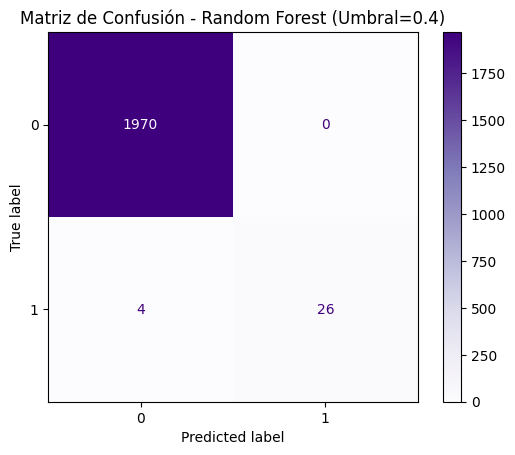

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Choose a new threshold (e.g., 0.6, or observe the curve for a suitable point)
new_threshold = 0.4 # Puedes cambiar este valor según la curva Precision-Recall

# Make predictions with the new threshold
y_pred_rf_adjusted = (y_pred_proba_rf >= new_threshold).astype(int)

# Evaluate the model with the adjusted threshold
print(f"\n--- Random Forest con Umbral Ajustado ({new_threshold}) ---")
print("Exactitud:", accuracy_score(y_test, y_pred_rf_adjusted))
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_rf_adjusted))

# Display the confusion matrix with the adjusted threshold
cm_rf_adjusted = confusion_matrix(y_test, y_pred_rf_adjusted)
disp_rf_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_rf_adjusted,
                                      display_labels=rf_pipeline.classes_)
disp_rf_adjusted.plot(cmap=plt.cm.Purples)
plt.title(f'Matriz de Confusión - Random Forest (Umbral={new_threshold})')
plt.show()

In [13]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 5-fold cross-validation on the Random Forest pipeline
cv_scores_rf = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print("--- Resultados de Validación Cruzada (Random Forest) ---")
print(f"Puntuaciones de Exactitud de Validación Cruzada: {cv_scores_rf}")
print(f"Exactitud Media de CV: {np.mean(cv_scores_rf):.4f}")
print(f"Desviación Estándar de CV: {np.std(cv_scores_rf):.4f}")

--- Resultados de Validación Cruzada (Random Forest) ---
Puntuaciones de Exactitud de Validación Cruzada: [0.995  0.9965 0.997  0.9945 0.994 ]
Exactitud Media de CV: 0.9954
Desviación Estándar de CV: 0.0012


## Prueba A/B: Regresión Logística vs. Random Forest Ajustado

Para realizar una prueba A/B, tomaremos dos subconjuntos aleatorios y disjuntos de 500 muestras cada uno de nuestro `X_test` y `y_test` originales. Luego, evaluaremos cada modelo (Regresión Logística y Random Forest con umbral 0.4) en su respectivo subconjunto y compararemos las métricas, especialmente el recall para la clase fraudulenta (clase 1).

In [14]:
from sklearn.model_selection import train_test_split

# Combine X_test and y_test for easier stratified splitting
X_test_combined = X_test.copy()
X_test_combined['is_fraud'] = y_test

# Split X_test_combined into two distinct groups of 500 samples each
# We'll use stratification to ensure fraud ratio is maintained in each group

# First group for Logistic Regression
X_ab_log_reg, X_remaining, y_ab_log_reg, y_remaining = train_test_split(
    X_test_combined.drop('is_fraud', axis=1),
    X_test_combined['is_fraud'],
    test_size=1000/len(X_test), # Remaining 1000 for the second group and discard the rest
    train_size=500/len(X_test), # 500 samples for log reg
    random_state=42,
    stratify=X_test_combined['is_fraud']
)

# Second group for Adjusted Random Forest from the remaining samples
X_ab_rf_adjusted, _, y_ab_rf_adjusted, _ = train_test_split(
    X_remaining,
    y_remaining,
    test_size=500/len(X_remaining), # Use 500 from the remaining 1500 (approx)
    train_size=500/len(X_remaining), # 500 samples for RF adjusted
    random_state=43, # Different random state for distinct split
    stratify=y_remaining
)

print(f"Tamaño del grupo A (Regresión Logística): {len(X_ab_log_reg)} muestras")
print(f"Tamaño del grupo B (Random Forest Ajustado): {len(X_ab_rf_adjusted)} muestras")

Tamaño del grupo A (Regresión Logística): 500 muestras
Tamaño del grupo B (Random Forest Ajustado): 500 muestras



--- Resultados para el Grupo A (Regresión Logística) ---
Exactitud: 0.992

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       492
           1       0.83      0.62      0.71         8

    accuracy                           0.99       500
   macro avg       0.91      0.81      0.86       500
weighted avg       0.99      0.99      0.99       500



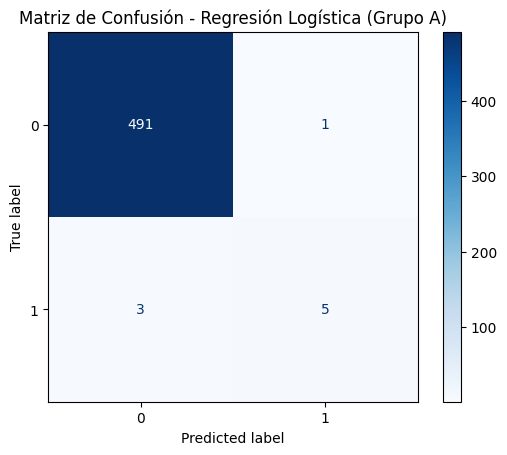

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Evaluación del Grupo A (Regresión Logística) ---
print("\n--- Resultados para el Grupo A (Regresión Logística) ---")

y_pred_ab_log_reg = log_reg_pipeline.predict(X_ab_log_reg)

print("Exactitud:", accuracy_score(y_ab_log_reg, y_pred_ab_log_reg))
print("\nInforme de Clasificación:")
print(classification_report(y_ab_log_reg, y_pred_ab_log_reg))

cm_ab_log_reg = confusion_matrix(y_ab_log_reg, y_pred_ab_log_reg)
disp_ab_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_ab_log_reg,
                                        display_labels=log_reg_pipeline.classes_)
disp_ab_log_reg.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Regresión Logística (Grupo A)')
plt.show()


--- Resultados para el Grupo B (Random Forest Ajustado - Umbral 0.4) ---
Exactitud: 0.998

Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       492
           1       1.00      0.88      0.93         8

    accuracy                           1.00       500
   macro avg       1.00      0.94      0.97       500
weighted avg       1.00      1.00      1.00       500



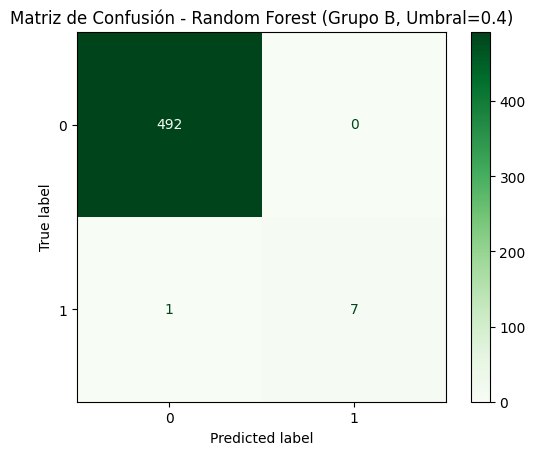

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Evaluación del Grupo B (Random Forest Ajustado con umbral 0.4) ---
print("\n--- Resultados para el Grupo B (Random Forest Ajustado - Umbral 0.4) ---")

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_ab_rf = rf_pipeline.predict_proba(X_ab_rf_adjusted)[:, 1]

# Apply the adjusted threshold (0.4 in this case)
new_threshold = 0.4 # Ensure this matches the adjusted threshold you want to test
y_pred_ab_rf_adjusted = (y_pred_proba_ab_rf >= new_threshold).astype(int)

print("Exactitud:", accuracy_score(y_ab_rf_adjusted, y_pred_ab_rf_adjusted))
print("\nInforme de Clasificación:")
print(classification_report(y_ab_rf_adjusted, y_pred_ab_rf_adjusted))

cm_ab_rf_adjusted = confusion_matrix(y_ab_rf_adjusted, y_pred_ab_rf_adjusted)
disp_ab_rf_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_ab_rf_adjusted,
                                            display_labels=rf_pipeline.classes_)
disp_ab_rf_adjusted.plot(cmap=plt.cm.Greens)
plt.title(f'Matriz de Confusión - Random Forest (Grupo B, Umbral={new_threshold})')
plt.show()

In [17]:
import joblib

joblib.dump(rf_pipeline, "best_model.pkl")
print("Modelo guardado como best_model.pkl")

Modelo guardado como best_model.pkl


In [18]:
import joblib
import numpy as np
import pandas as pd

loaded_model = joblib.load("best_model.pkl")

# The sample array must be converted to a DataFrame with the correct column names
# and data types that the model was trained with.
# merchant_category needs to be a string type, matching the training data.
column_names = ['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

# Instead of a NumPy array, create a dictionary to preserve data types correctly,
# especially for the 'merchant_category' which should be a string.
sample_data_dict = {
    'transaction_id': 12345,
    'amount': 250.75,
    'transaction_hour': 14,
    'merchant_category': 'Grocery', # Changed to a string category, e.g., 'Grocery'
    'foreign_transaction': 0,
    'location_mismatch': 1,
    'device_trust_score': 0.85,
    'velocity_last_24h': 5.0,
    'cardholder_age': 32
}
sample_df = pd.DataFrame([sample_data_dict], columns=column_names)

print(loaded_model.predict(sample_df))
print(loaded_model.predict_proba(sample_df))

[0]
[[0.52 0.48]]


In [19]:
from pydantic import BaseModel

class FraudRequest(BaseModel):
    transaction_id: int
    amount: float
    transaction_hour: int
    merchant_category: str # Corrected type to str for OneHotEncoder compatibility
    foreign_transaction: int
    location_mismatch: int
    device_trust_score: float
    velocity_last_24h: float
    cardholder_age: int

class FraudResponse(BaseModel):
    fraud_probability: float
    is_fraud: bool

In [20]:
from fastapi import FastAPI
import numpy as np
import joblib
import pandas as pd # Import pandas for DataFrame creation

# FraudRequest and FraudResponse are now globally available after cell cqD1MYO2Ci2Y execution.
# No need to import from 'backend.schemas' or redefine them.

# Load the model directly, as 'backend.model_loader' does not exist in this environment.
model = joblib.load("best_model.pkl")

app = FastAPI(title="Fraud Risk API")

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict", response_model=FraudResponse)
def predict(request: FraudRequest):

    # The input features must be transformed into a Pandas DataFrame
    # with the correct column names and data types, similar to how the model was trained.
    column_names = ['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
                    'foreign_transaction', 'location_mismatch', 'device_trust_score',
                    'velocity_last_24h', 'cardholder_age']

    # Create a dictionary to maintain correct data types, especially for 'merchant_category'
    input_data = {
        'transaction_id': request.transaction_id,
        'amount': request.amount,
        'transaction_hour': request.transaction_hour,
        'merchant_category': request.merchant_category, # Now correctly expected as a string
        'foreign_transaction': request.foreign_transaction,
        'location_mismatch': request.location_mismatch,
        'device_trust_score': request.device_trust_score,
        'velocity_last_24h': request.velocity_last_24h,
        'cardholder_age': request.cardholder_age
    }

    # Convert to DataFrame before passing to the model
    features_df = pd.DataFrame([input_data], columns=column_names)

    proba = model.predict_proba(features_df)[0, 1]

    return FraudResponse(
        fraud_probability=float(proba),
        is_fraud=proba >= 0.5
    )

In [21]:
import joblib
# Removed 'from pathlib import Path' as it's no longer needed for path construction

# The model is saved directly as 'best_model.pkl' in the current working directory.
# We can load it directly without complex path manipulation.
MODEL_PATH = "best_model.pkl"

def load_model():
    return joblib.load(MODEL_PATH)

model = load_model()

In [22]:
# tests/test_api.py
from fastapi.testclient import TestClient
# No need to import app, it's globally available from a previous cell.
# from backend.main import app

client = TestClient(app)

def test_predict():
    payload = {
        "transaction_id": 12345,
        "amount": 250.75,
        "transaction_hour": 14,
        "merchant_category": "Grocery", # Changed from int (3) to string ('Grocery')
        "foreign_transaction": 0,
        "location_mismatch": 1,
        "device_trust_score": 0.85,
        "velocity_last_24h": 5.0,
        "cardholder_age": 32
    }
    resp = client.post("/predict", json=payload)
    assert resp.status_code == 200
    # Optionally, you can assert more about the response content:
    # assert resp.json()['is_fraud'] is False or True
    # assert 'fraud_probability' in resp.json()

In [23]:
test_predict()

In [24]:
df_10k['merchant_category'].unique()

array(['Electronics', 'Travel', 'Grocery', 'Food', 'Clothing'],
      dtype=object)

In [26]:
df_10k.dtypes

,0
transaction_id,int64
amount,float64
transaction_hour,int64
merchant_category,object
foreign_transaction,int64
location_mismatch,int64
device_trust_score,int64
velocity_last_24h,int64
cardholder_age,int64
is_fraud,int64
